Starting XGBoost Time-Series Cross-Validation...
Fold 1 completed: R²=0.8714, NMSE=0.0088, NMAE=0.0453
Fold 2 completed: R²=0.4512, NMSE=0.0282, NMAE=0.0588
Fold 3 completed: R²=0.9201, NMSE=0.0047, NMAE=0.0330
Fold 4 completed: R²=0.9716, NMSE=0.0019, NMAE=0.0210
Fold 5 completed: R²=0.9739, NMSE=0.0014, NMAE=0.0205

========= XGBOOST TIME-SERIES CV RESULTS =========
NMAE : 0.0357 ± 0.0147
NMSE : 0.0090 ± 0.0100
R²   : 0.8377 ± 0.1969
MAPE : 16.02% ± 7.98%

========== DIEBOLD-MARIANO TEST RESULT ==========
Comparison : XGBoost Prediction vs. Naive Baseline (Lag 12)
DM Stat    : -5.5134
p-value    : 0.0000


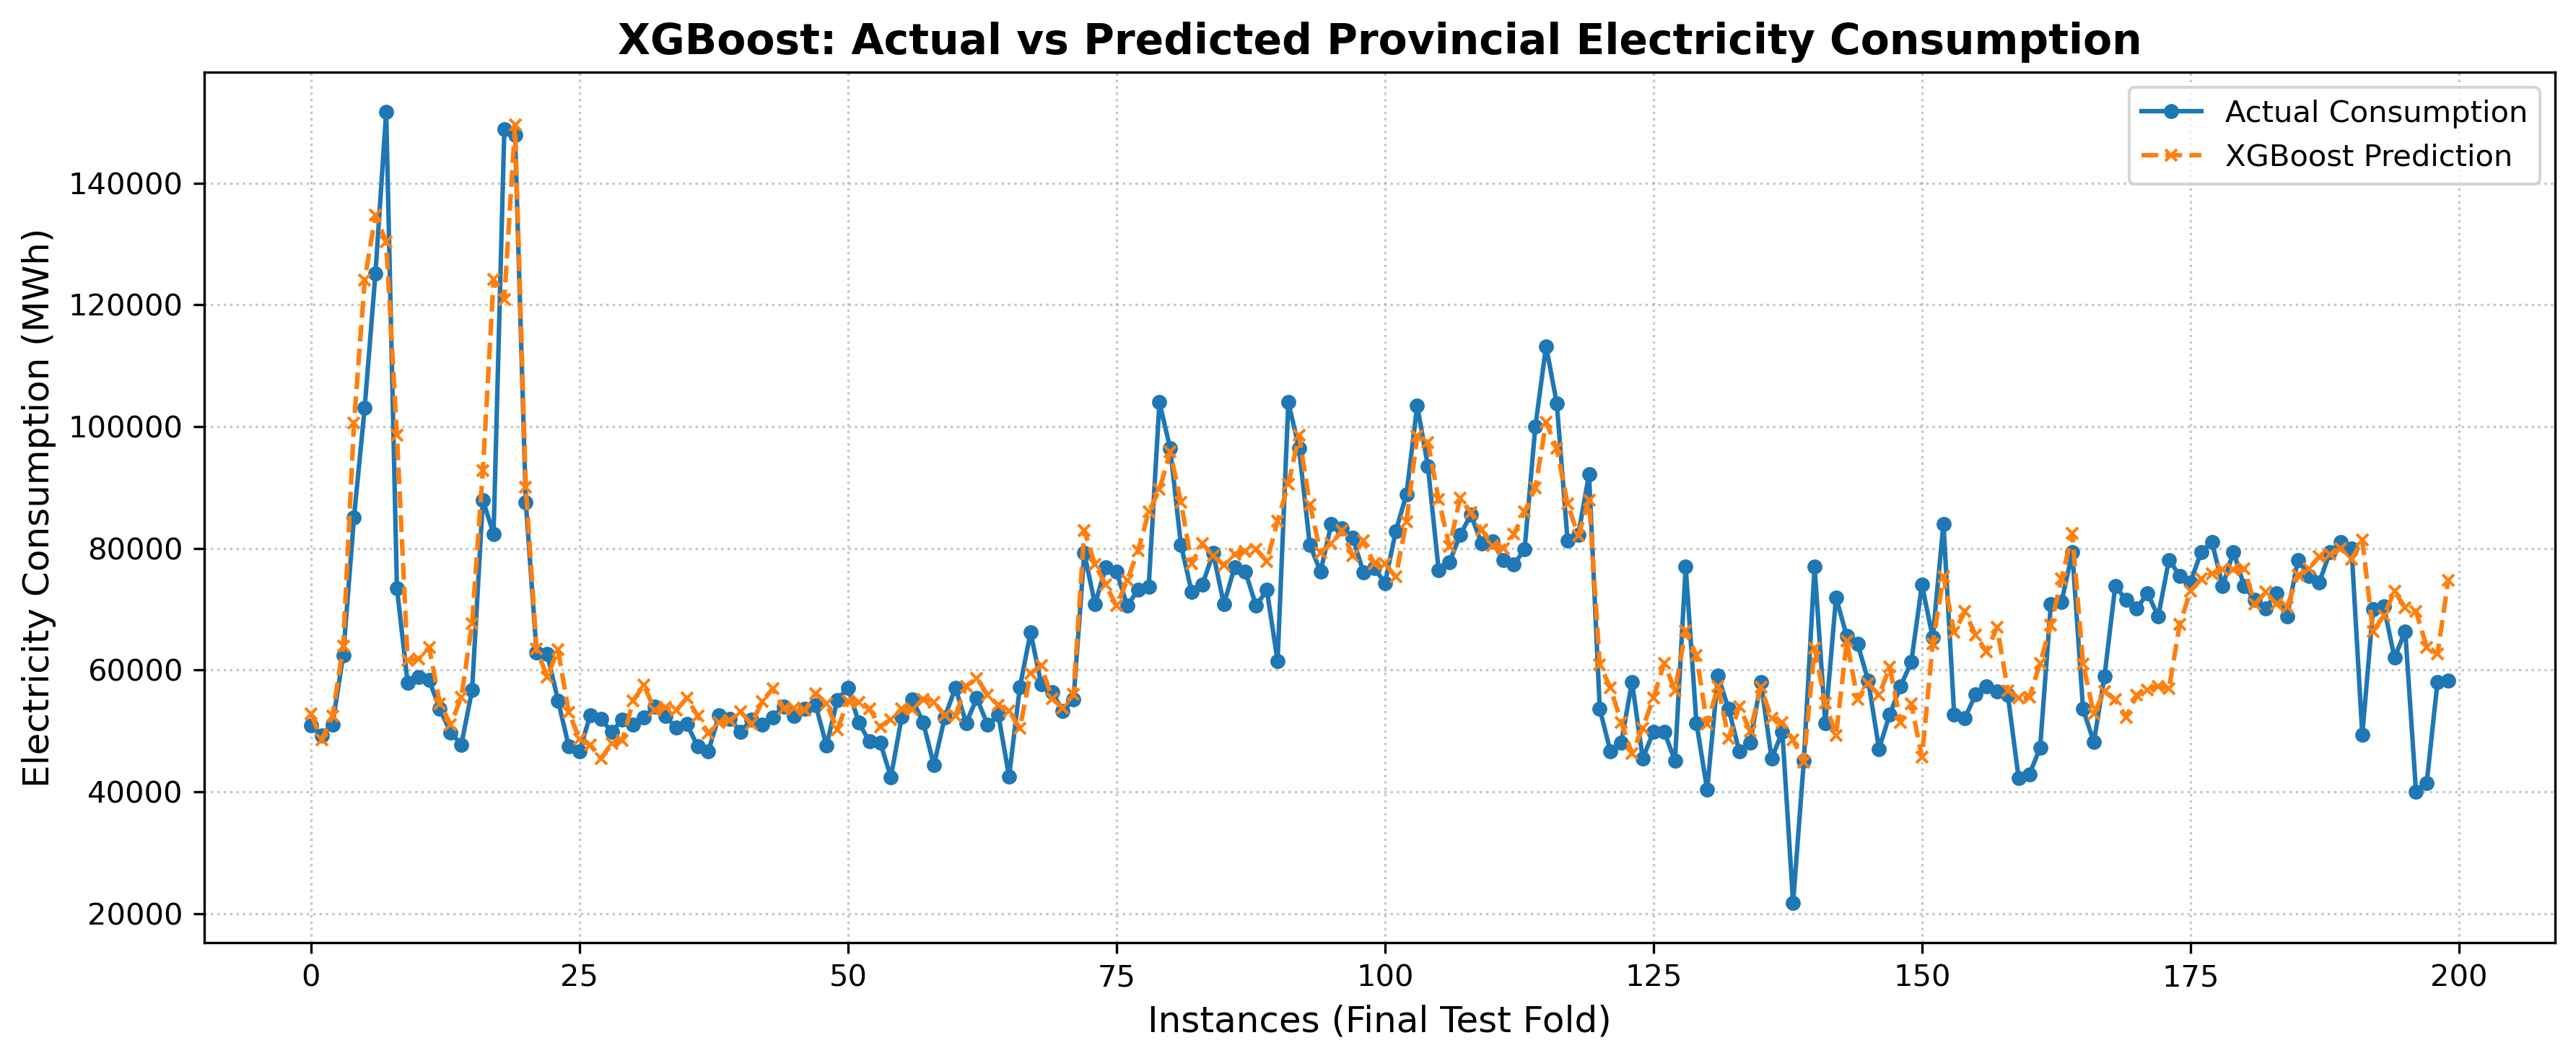

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ---------------------------------------------------------
# 1) DIEBOLD-MARIANO TEST FUNCTION
# ---------------------------------------------------------
def diebold_mariano(y_true, y_pred1, y_pred2):
    e1 = y_true - y_pred1
    e2 = y_true - y_pred2

    d = e1**2 - e2**2

    mean_d = np.mean(d)
    var_d = np.var(d, ddof=1)

    dm_stat = mean_d / np.sqrt(var_d / len(d))
    p_value = 2 * (1 - stats.norm.cdf(np.abs(dm_stat)))

    return dm_stat, p_value


def main():

    # ---------------------------------------------------------
    # 2) DATA LOADING
    # ---------------------------------------------------------
    OUTPUT_PATH = os.path.join(
        "..", "..", "processed_data", "final", "ML_En.xlsx"
    )

    df = pd.read_excel(OUTPUT_PATH)

    df["Plate"] = df["Plate"].astype(str).str.lower()
    df = df.sort_values(["Plate", "Year", "Month"]).reset_index(drop=True)

    # ---------------------------------------------------------
    # 3) LAG FEATURES
    # ---------------------------------------------------------
    lag = 12

    for l in range(1, lag + 1):
        df[f"lag_{l}"] = (
            df.groupby("Plate")["Consumption"]
            .shift(l)
        )

    df = df.dropna().reset_index(drop=True)

    # ---------------------------------------------------------
    # 4) FEATURE ENGINEERING
    # ---------------------------------------------------------
    features = [
        "Lighting",
        "Public",
        "Residential",
        "Industry",
        "Agriculture",
        "Population",
        "Month",
        "Season",
        "Region",
        "Latitude",
        "Longitude",
        "Daylight Duration",
        "Altitude"
    ] + [f"lag_{i}" for i in range(1, lag + 1)]

    X = df[features].copy()
    y = df["Consumption"].values

    # ---------------------------------------------------------
    # 5) TIME SERIES CROSS-VALIDATION
    # ---------------------------------------------------------
    tscv = TimeSeriesSplit(n_splits=5)

    fold_metrics = []

    print("Starting XGBoost Time-Series Cross-Validation...")

    final_y_true = None
    final_y_pred = None

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X), 1):

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model = XGBRegressor(
            n_estimators=1000,
            learning_rate=0.03,
            max_depth=6,
            min_child_weight=3,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=1.0,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1
        )

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        # -----------------------------------------------------
        # METRICS
        # -----------------------------------------------------
        y_range = y_test.max() - y_test.min()
        y_range_safe = y_range if y_range != 0 else 1

        mse_val = mean_squared_error(y_test, y_pred)
        mae_val = mean_absolute_error(y_test, y_pred)

        nmse = mse_val / (y_range_safe ** 2)
        nmae = mae_val / y_range_safe

        r2 = r2_score(y_test, y_pred)

        mape = np.mean(
            np.abs((y_test - y_pred) /
                   (np.abs(y_test) + 1e-10))
        ) * 100

        fold_metrics.append(
            [r2, nmse, nmae, mape]
        )

        print(
            f"Fold {fold} completed: "
            f"R²={r2:.4f}, "
            f"NMSE={nmse:.4f}, "
            f"NMAE={nmae:.4f}"
        )

        if fold == tscv.n_splits:
            final_y_true = y_test
            final_y_pred = y_pred

    # ---------------------------------------------------------
    # 6) CV RESULTS
    # ---------------------------------------------------------
    fold_metrics = np.array(fold_metrics)

    print("\n" + "=" * 50)
    print("========= XGBOOST TIME-SERIES CV RESULTS =========")
    print("=" * 50)

    print(
        f"NMAE : "
        f"{fold_metrics[:, 2].mean():.4f} ± "
        f"{fold_metrics[:, 2].std():.4f}"
    )

    print(
        f"NMSE : "
        f"{fold_metrics[:, 1].mean():.4f} ± "
        f"{fold_metrics[:, 1].std():.4f}"
    )

    print(
        f"R²   : "
        f"{fold_metrics[:, 0].mean():.4f} ± "
        f"{fold_metrics[:, 0].std():.4f}"
    )

    print(
        f"MAPE : "
        f"{fold_metrics[:, 3].mean():.2f}% ± "
        f"{fold_metrics[:, 3].std():.2f}%"
    )

    print("=" * 50)

    # ---------------------------------------------------------
    # 7) DIEBOLD-MARIANO TEST
    # ---------------------------------------------------------
    y_naive = (
        pd.Series(final_y_true)
        .shift(12)
        .bfill()
        .values
    )

    dm_stat, p_value = diebold_mariano(
        final_y_true,
        final_y_pred,
        y_naive
    )

    print("\n" + "=" * 50)
    print("========== DIEBOLD-MARIANO TEST RESULT ==========")
    print("=" * 50)

    print(
        "Comparison : XGBoost Prediction "
        "vs. Naive Baseline (Lag 12)"
    )

    print(f"DM Stat    : {dm_stat:.4f}")
    print(f"p-value    : {p_value:.4f}")

    print("=" * 50)

    # ---------------------------------------------------------
    # 8) PLOT
    # ---------------------------------------------------------
    plt.figure(figsize=(12, 5), dpi=300)

    plot_limit = min(200, len(final_y_true))

    plt.plot(
        final_y_true[:plot_limit],
        label="Actual Consumption",
        color="#1f77b4",
        marker="o",
        markersize=4,
        linewidth=1.5
    )

    plt.plot(
        final_y_pred[:plot_limit],
        label="XGBoost Prediction",
        color="#ff7f0e",
        marker="x",
        markersize=4,
        linestyle="--",
        linewidth=1.5
    )

    plt.title(
        "XGBoost: Actual vs Predicted Provincial Electricity Consumption",
        fontsize=14,
        fontweight="bold"
    )

    plt.xlabel(
        "Instances (Final Test Fold)",
        fontsize=12
    )

    plt.ylabel(
        "Electricity Consumption (MWh)",
        fontsize=12
    )

    plt.legend()
    plt.grid(True, linestyle=":", alpha=0.7)

    plt.tight_layout()

    plt.savefig(
        "xgboost_n_metrics_plot.png",
        bbox_inches="tight"
    )

    plt.show()


if __name__ == "__main__":
    main()